In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
PROJECT_ROOT = Path("../../").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "echo" / "echonet"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "eda" / "echonet"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Data directory:", DATA_DIR)
print("Exists:", DATA_DIR.exists())
print("Artifact directory:", ARTIFACT_DIR)

Data directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\raw\echo\echonet
Exists: True
Artifact directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\echonet


In [3]:
required_paths = {
    "FileList.csv": DATA_DIR / "FileList.csv",
    "VolumeTracings.csv": DATA_DIR / "VolumeTracings.csv",
    "Videos": DATA_DIR / "Videos",
}

for name, path in required_paths.items():
    print(f"{name}: {'FOUND' if path.exists() else 'MISSING'}")

FileList.csv: FOUND
VolumeTracings.csv: FOUND
Videos: FOUND


In [4]:
filelist_path = DATA_DIR / "FileList.csv"
tracings_path = DATA_DIR / "VolumeTracings.csv"

filelist = pd.read_csv(filelist_path)
tracings = pd.read_csv(tracings_path)

print("FileList shape:", filelist.shape)
print("VolumeTracings shape:", tracings.shape)

FileList shape: (10030, 9)
VolumeTracings shape: (425010, 6)


In [5]:
print("FileList columns:")
print(filelist.columns.tolist())

print("\nVolumeTracings columns:")
print(tracings.columns.tolist())

FileList columns:
['FileName', 'EF', 'ESV', 'EDV', 'FrameHeight', 'FrameWidth', 'FPS', 'NumberOfFrames', 'Split']

VolumeTracings columns:
['FileName', 'X1', 'Y1', 'X2', 'Y2', 'Frame']


In [6]:
print("FileList:")
display(filelist.head())

print("\nVolumeTracings:")
display(tracings.head())

print("\nFileList dtypes:")
print(filelist.dtypes)

print("\nVolumeTracings dtypes:")
print(tracings.dtypes)

FileList:


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL



VolumeTracings:


,FileName,X1,Y1,X2,Y2,Frame
0,0X100009310A3BD7FC.avi,51.260417,15.348958,64.932292,69.125000,46
1,0X100009310A3BD7FC.avi,50.037611,17.167841,53.367222,16.321330,46
2,0X100009310A3BD7FC.avi,49.157378,20.407629,57.090549,18.390722,46
3,0X100009310A3BD7FC.avi,48.538173,23.581055,59.997339,20.667707,46
4,0X100009310A3BD7FC.avi,47.918968,26.754480,62.904129,22.944693,46



FileList dtypes:
FileName           object
EF                float64
ESV               float64
EDV               float64
FrameHeight         int64
FrameWidth          int64
FPS                 int64
NumberOfFrames      int64
Split              object
dtype: object

VolumeTracings dtypes:
FileName     object
X1          float64
Y1          float64
X2          float64
Y2          float64
Frame         int64
dtype: object


In [7]:
print("Missing values in FileList:")
print(filelist.isna().sum())

print("\nMissing values in VolumeTracings:")
print(tracings.isna().sum())

Missing values in FileList:
FileName          0
EF                0
ESV               0
EDV               0
FrameHeight       0
FrameWidth        0
FPS               0
NumberOfFrames    0
Split             0
dtype: int64

Missing values in VolumeTracings:
FileName    0
X1          0
Y1          0
X2          0
Y2          0
Frame       0
dtype: int64


In [8]:
target_columns = [c for c in ["EF", "EDV", "ESV"] if c in filelist.columns]

print("Available target columns:", target_columns)

if target_columns:
    display(filelist[target_columns].describe().T)

Available target columns: ['EF', 'EDV', 'ESV']


,count,mean,std,min,25%,50%,75%,max
EF,10030.0,55.748248,12.371483,6.907258,51.601387,59.209109,63.958740,96.967237
EDV,10030.0,91.324572,45.663554,12.618671,62.166669,82.084190,108.288686,695.036025
ESV,10030.0,43.427433,35.828098,4.350710,23.686339,33.596750,49.107316,612.489815


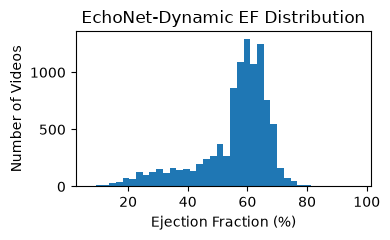

In [9]:
if "EF" in filelist.columns:
    plt.figure(figsize=(4, 2.5))
    plt.hist(filelist["EF"].dropna(), bins=40)
    plt.xlabel("Ejection Fraction (%)")
    plt.ylabel("Number of Videos")
    plt.title("EchoNet-Dynamic EF Distribution")
    plt.tight_layout()
    plt.show()

In [10]:
if "EF" in filelist.columns:
    ef = filelist["EF"].dropna()

    lv_dysfunction = (ef < 50).sum()
    reduced_ef = (ef < 40).sum()

    print(f"EF < 50%: {lv_dysfunction} ({lv_dysfunction / len(ef) * 100:.2f}%)")
    print(f"EF < 40%: {reduced_ef} ({reduced_ef / len(ef) * 100:.2f}%)")

EF < 50%: 2246 (22.39%)
EF < 40%: 1264 (12.60%)


In [11]:
for col in target_columns:
    values = filelist[col].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((values < lower) | (values > upper)).sum()

    print(
        f"{col}: "
        f"min={values.min():.2f}, "
        f"max={values.max():.2f}, "
        f"IQR outliers={outliers}"
    )

EF: min=6.91, max=96.97, IQR outliers=832
EDV: min=12.62, max=695.04, IQR outliers=460
ESV: min=4.35, max=612.49, IQR outliers=789


In [12]:
print("FileList columns:", filelist.columns.tolist())

split_column = None

for candidate in ["Split", "split", "SPLIT"]:
    if candidate in filelist.columns:
        split_column = candidate
        break

if split_column:
    print("\nSplit distribution:")
    print(filelist[split_column].value_counts(dropna=False))
else:
    print("No split column found in FileList.csv.")

FileList columns: ['FileName', 'EF', 'ESV', 'EDV', 'FrameHeight', 'FrameWidth', 'FPS', 'NumberOfFrames', 'Split']

Split distribution:
Split
TRAIN    7465
VAL      1288
TEST     1277
Name: count, dtype: int64


In [13]:
video_dir = DATA_DIR / "Videos"

if video_dir.exists():
    video_files = list(video_dir.glob("*.avi")) + list(video_dir.glob("*.mp4")) + list(video_dir.glob("*.mov"))
    
    print("Video files found:", len(video_files))
    
    if video_files:
        print("Example video:", video_files[0].name)
else:
    print("Videos directory not found.")

Video files found: 1530
Example video: 0X100009310A3BD7FC.avi


In [14]:
video_names = {
    p.name for p in video_dir.iterdir()
    if p.is_file()
} if video_dir.exists() else set()

print("Video files on disk:", len(video_names))

for candidate in ["FileName", "Filename", "filename"]:
    if candidate in filelist.columns:
        metadata_names = filelist[candidate].astype(str)
        matched = metadata_names.isin(video_names).sum()

        print("Metadata filename column:", candidate)
        print("Matched:", matched)
        print("Unmatched:", len(metadata_names) - matched)
        break
else:
    print("No obvious filename column found.")

Video files on disk: 1530
Metadata filename column: FileName
Matched: 0
Unmatched: 10030


In [15]:
if video_dir.exists():
    video_files = [
        p for p in video_dir.iterdir()
        if p.is_file() and p.suffix.lower() in [".avi", ".mp4", ".mov"]
    ]

    if video_files:
        sample_video = video_files[0]

        cap = cv2.VideoCapture(str(sample_video))

        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        print("Video:", sample_video.name)
        print("Frames:", frame_count)
        print("FPS:", fps)
        print("Resolution:", width, "x", height)

        cap.release()

Video: 0X100009310A3BD7FC.avi
Frames: 174
FPS: 50.0
Resolution: 112 x 112


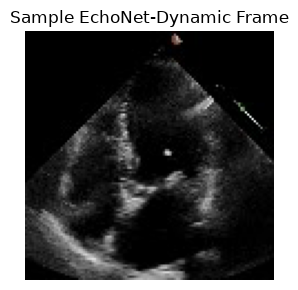

In [16]:
cap = cv2.VideoCapture(str(sample_video))

ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 3))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title("Sample EchoNet-Dynamic Frame")
    plt.tight_layout()
    plt.show()

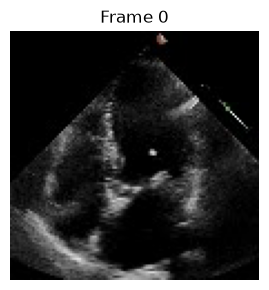

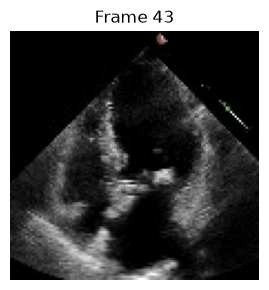

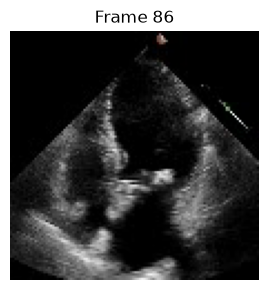

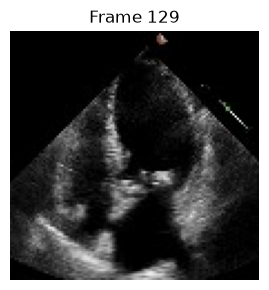

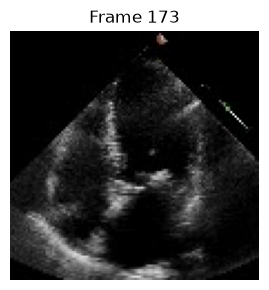

In [17]:
cap = cv2.VideoCapture(str(sample_video))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

indices = np.linspace(
    0,
    max(total_frames - 1, 0),
    5,
    dtype=int
)

frames = []

for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ret, frame = cap.read()

    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((idx, frame))

cap.release()

for idx, frame in frames:
    plt.figure(figsize=(4, 3))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(f"Frame {idx}")
    plt.tight_layout()
    plt.show()

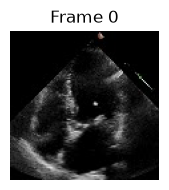

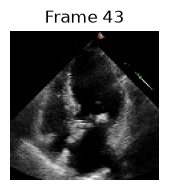

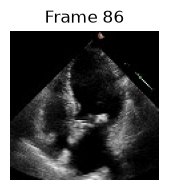

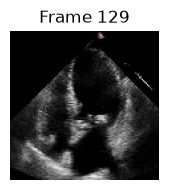

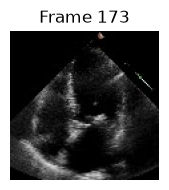

In [18]:
cap = cv2.VideoCapture(str(sample_video))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

indices = np.linspace(
    0,
    max(total_frames - 1, 0),
    5,
    dtype=int
)

frames = []

for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ret, frame = cap.read()

    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((idx, frame))

cap.release()

for idx, frame in frames:
    plt.figure(figsize=(3, 2))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(f"Frame {idx}")
    plt.tight_layout()
    plt.show()

In [19]:
summary = {
    "filelist_rows": len(filelist),
    "filelist_columns": len(filelist.columns),
    "tracing_rows": len(tracings),
    "video_files": len(video_names),
}

if "EF" in filelist.columns:
    summary.update({
        "ef_mean": filelist["EF"].mean(),
        "ef_std": filelist["EF"].std(),
        "ef_min": filelist["EF"].min(),
        "ef_max": filelist["EF"].max(),
        "ef_below_50": int((filelist["EF"] < 50).sum()),
        "ef_below_40": int((filelist["EF"] < 40).sum()),
    })

summary_df = pd.DataFrame([summary])

display(summary_df)

summary_df.to_csv(
    ARTIFACT_DIR / "echonet_eda_summary.csv",
    index=False
)

print("Saved:", ARTIFACT_DIR / "echonet_eda_summary.csv")

,filelist_rows,filelist_columns,tracing_rows,video_files,ef_mean,ef_std,ef_min,ef_max,ef_below_50,ef_below_40
0,10030,9,425010,1530,55.748248,12.371483,6.907258,96.967237,2246,1264


Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\echonet\echonet_eda_summary.csv
